# South German Credit exploratory data analysis

This notebook profiles the corrected South German Credit dataset from the UCI
Machine Learning Repository (dataset 573; DOI: 10.24432/C5QG88). The dataset is
licensed under CC BY 4.0.

The analysis describes data quality and class structure. It does not establish
production suitability or a validated probability of default.

## Reproducibility and source

The loader downloads the official UCI archive, verifies fixed SHA-256 checksums,
preserves the source files in the ignored `data/raw` directory, and creates a
normalized CSV with descriptive English field names.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.download_data import download_dataset, validate_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

In [2]:
dataset_path = download_dataset(ROOT / "data" / "raw")
data = pd.read_csv(dataset_path)
validate_dataset(data)

print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
data.head()

Rows: 1,000
Columns: 22


,checking_account_status,duration_months,credit_history,purpose,credit_amount_dm,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age_years,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk,bad_credit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1,0
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1,0
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1,0
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1,0
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1,0


## Schema, missing values, and duplicate records

In [3]:
schema = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_count": data.isna().sum(),
    "missing_percent": data.isna().mean().mul(100).round(2),
    "unique_values": data.nunique(),
})
schema

,dtype,missing_count,missing_percent,unique_values
checking_account_status,int64,0,0.0,4
duration_months,int64,0,0.0,33
credit_history,int64,0,0.0,5
purpose,int64,0,0.0,10
credit_amount_dm,int64,0,0.0,923
savings,int64,0,0.0,5
employment_duration,int64,0,0.0,5
installment_rate,int64,0,0.0,4
personal_status_sex,int64,0,0.0,4
other_debtors,int64,0,0.0,3


In [4]:
quality_summary = pd.Series({
    "rows": len(data),
    "columns": data.shape[1],
    "duplicate_rows": int(data.duplicated().sum()),
    "missing_cells": int(data.isna().sum().sum()),
    "constant_columns": int((data.nunique() <= 1).sum()),
}, name="value")
quality_summary.to_frame()

,value
rows,1000
columns,22
duplicate_rows,0
missing_cells,0
constant_columns,0


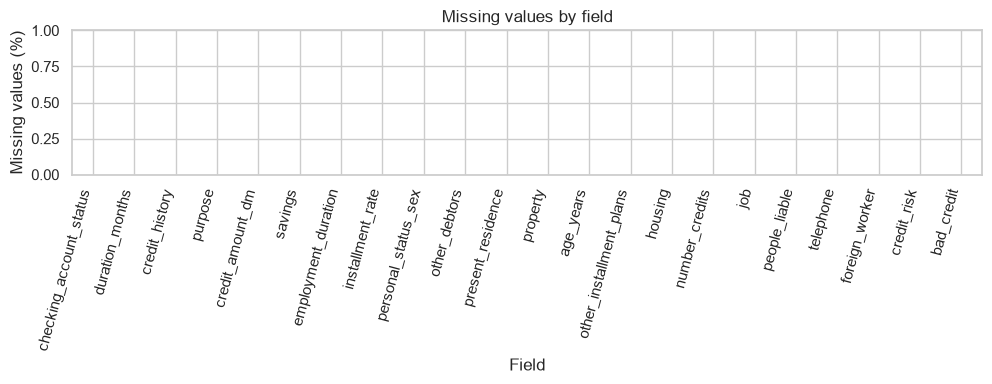

In [5]:
missing = data.isna().mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
missing.plot(kind="bar", ax=ax, color="#315b7d")
ax.set(title="Missing values by field", xlabel="Field", ylabel="Missing values (%)")
ax.set_ylim(0, max(1, missing.max() * 1.15))
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## Target definition and class balance

The UCI outcome `credit_risk` uses `0 = bad` and `1 = good`. The modeling label
is `bad_credit = 1 - credit_risk`, so the positive class means failed contract
compliance. Both label columns must be excluded from model features.

In [6]:
target_counts = data["bad_credit"].value_counts().sort_index().rename(index={0: "good", 1: "bad"})
target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": (target_counts / len(data) * 100).round(1),
})
target_summary

,count,percent
bad_credit,,
good,700,70.0
bad,300,30.0


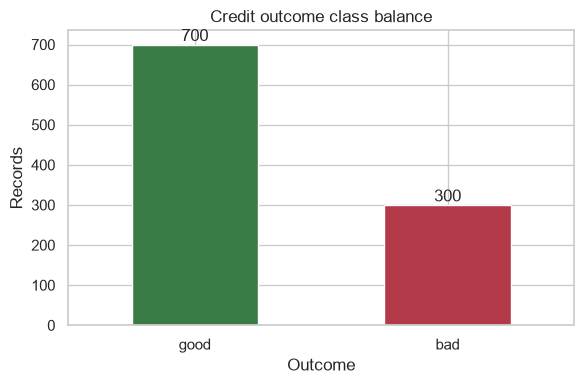

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax, color=["#3a7d44", "#b23a48"])
ax.set(title="Credit outcome class balance", xlabel="Outcome", ylabel="Records")
ax.tick_params(axis="x", rotation=0)
for patch in ax.patches:
    label_position = (patch.get_x() + patch.get_width() / 2, patch.get_height())
    ax.annotate(
        f"{int(patch.get_height())}", label_position, ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

## Numeric distributions

In [8]:
numeric_fields = ["duration_months", "credit_amount_dm", "age_years"]
data[numeric_fields].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
duration_months,1000.0,20.903,12.058814,4.0,6.00,12.0,18.0,24.00,60.00,72.0
credit_amount_dm,1000.0,3271.248,2822.751760,250.0,425.83,1365.5,2319.5,3972.25,14180.39,18424.0
age_years,1000.0,35.542,11.352670,19.0,20.00,27.0,33.0,42.00,67.01,75.0


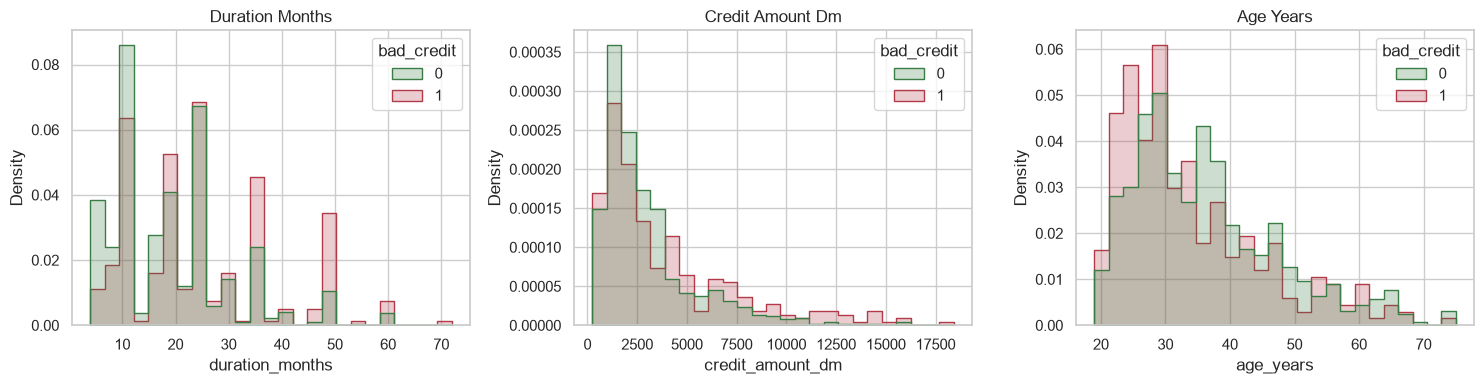

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for field, ax in zip(numeric_fields, axes):
    sns.histplot(data=data, x=field, hue="bad_credit", bins=25, element="step", stat="density",
                 common_norm=False, ax=ax, palette={0: "#3a7d44", 1: "#b23a48"})
    ax.set_title(field.replace("_", " ").title())
plt.tight_layout()
plt.show()

## Categorical and ordinal distributions

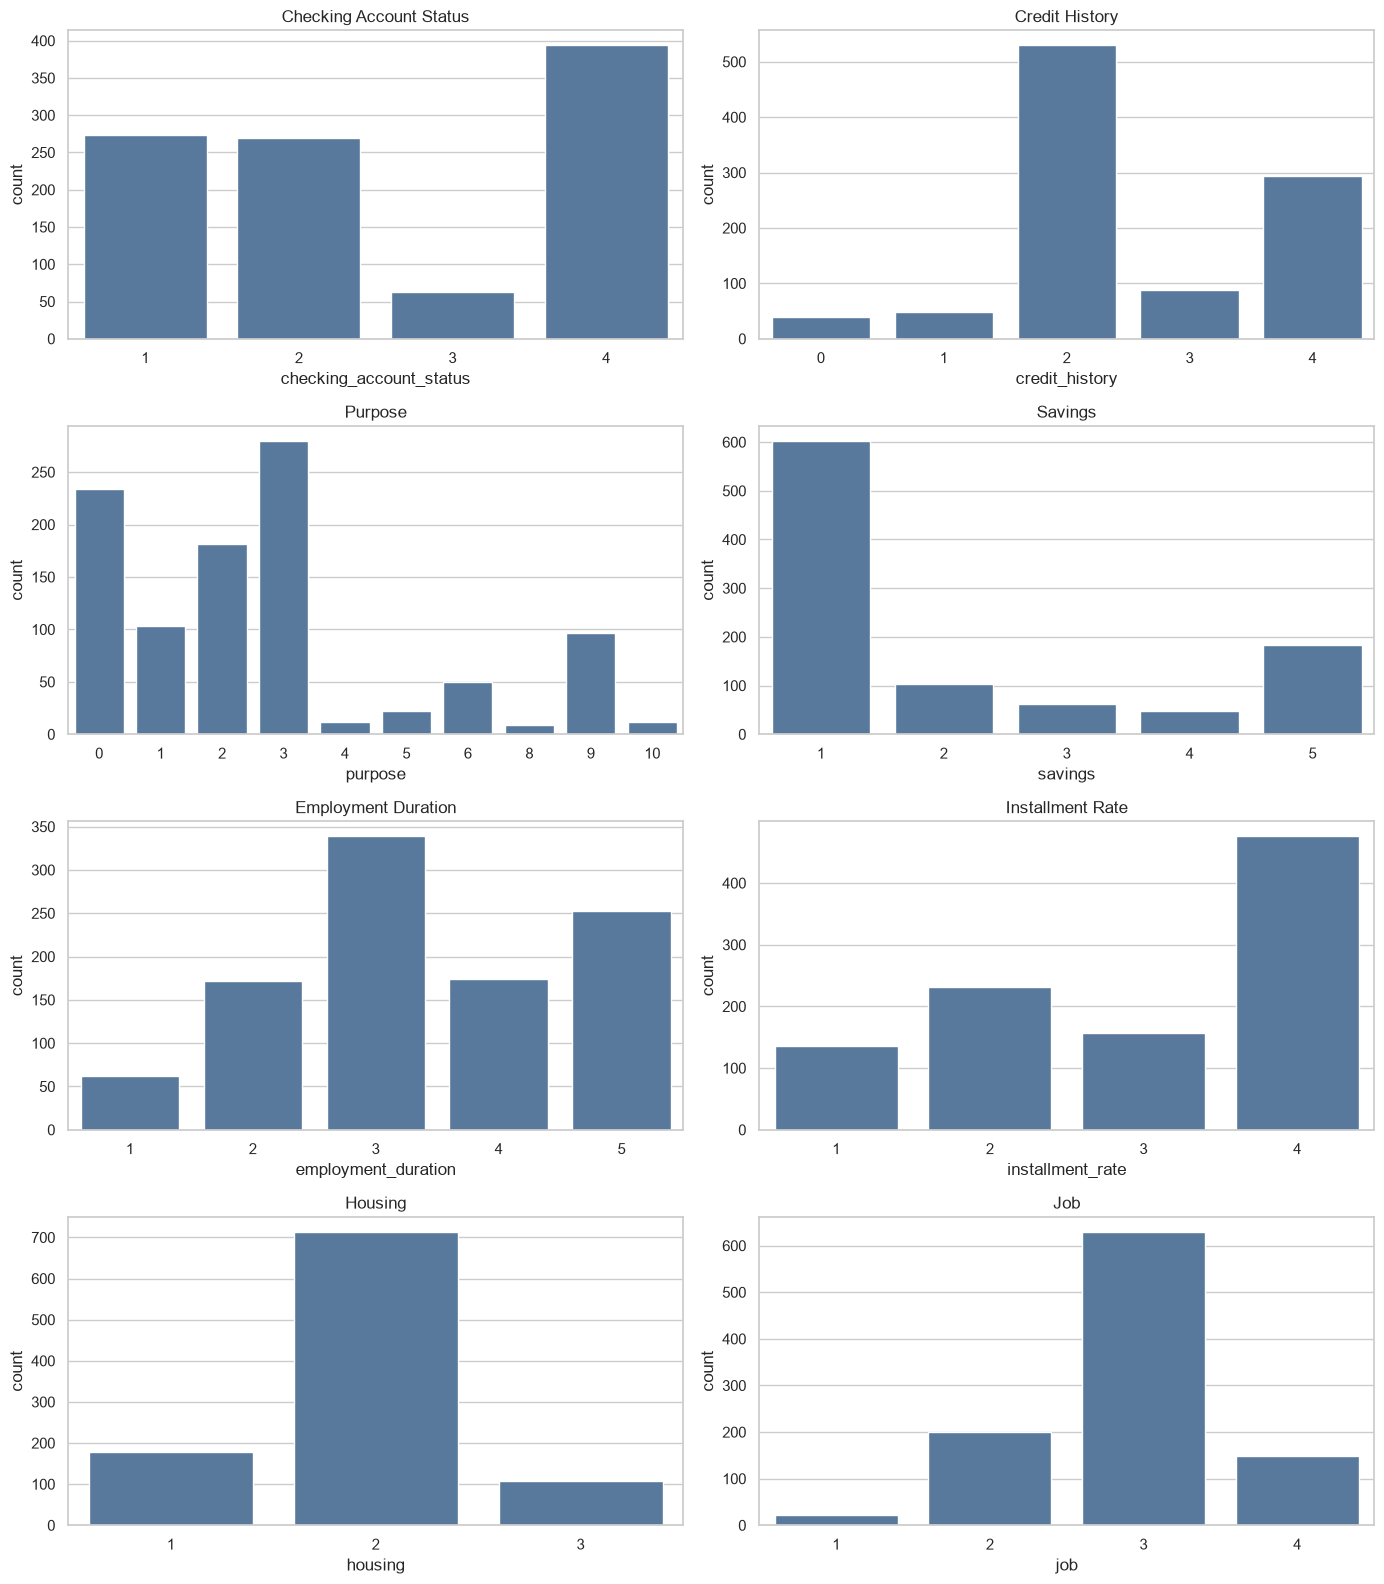

In [10]:
categorical_fields = [
    "checking_account_status", "credit_history", "purpose", "savings",
    "employment_duration", "installment_rate", "housing", "job",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for field, ax in zip(categorical_fields, axes.flat):
    order = sorted(data[field].unique())
    sns.countplot(data=data, x=field, order=order, ax=ax, color="#4c78a8")
    ax.set_title(field.replace("_", " ").title())
plt.tight_layout()
plt.show()

## Outcome rates across selected indicators

In [11]:
rate_fields = ["checking_account_status", "credit_history", "savings", "duration_months"]
rate_tables = {}
for field in rate_fields:
    rate_tables[field] = (
        data.groupby(field, observed=True)["bad_credit"]
        .agg(records="size", bad_credit_rate="mean")
        .assign(bad_credit_rate=lambda frame: frame["bad_credit_rate"].round(3))
    )

rate_tables["checking_account_status"]

,records,bad_credit_rate
checking_account_status,,
1,274,0.493
2,269,0.390
3,63,0.222
4,394,0.117


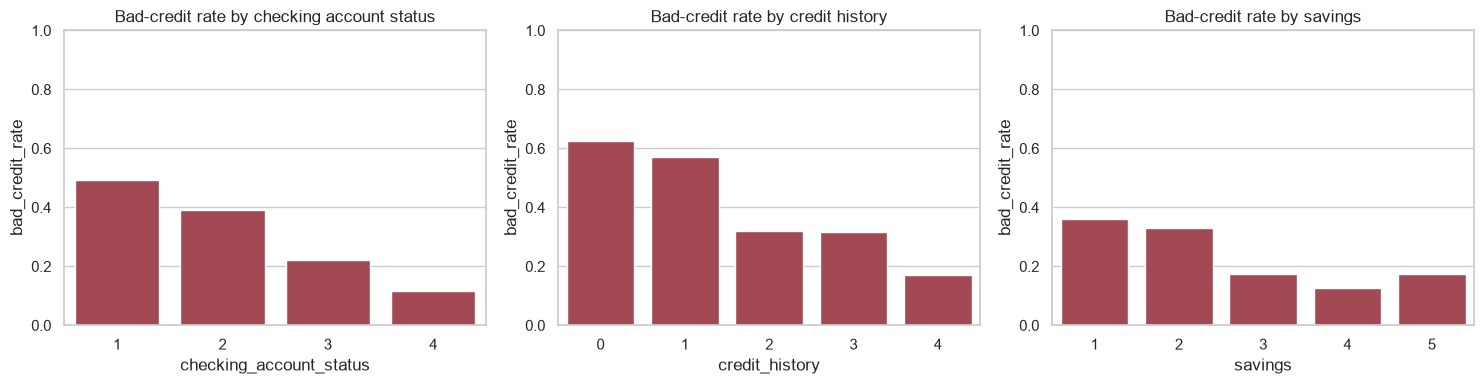

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for field, ax in zip(["checking_account_status", "credit_history", "savings"], axes):
    rates = rate_tables[field].reset_index()
    sns.barplot(data=rates, x=field, y="bad_credit_rate", ax=ax, color="#b23a48")
    ax.set_ylim(0, 1)
    ax.set_title(f"Bad-credit rate by {field.replace('_', ' ')}")
plt.tight_layout()
plt.show()

## Range and consistency checks

In [13]:
checks = {
    "duration_positive": bool((data["duration_months"] > 0).all()),
    "amount_positive": bool((data["credit_amount_dm"] > 0).all()),
    "age_positive": bool((data["age_years"] > 0).all()),
    "credit_risk_binary": set(data["credit_risk"]) == {0, 1},
    "bad_credit_binary": set(data["bad_credit"]) == {0, 1},
    "target_inverse_consistent": bool((data["bad_credit"] == 1 - data["credit_risk"]).all()),
}
pd.Series(checks, name="passed").to_frame()

,passed
duration_positive,True
amount_positive,True
age_positive,True
credit_risk_binary,True
bad_credit_binary,True
target_inverse_consistent,True


## Data quality, leakage, and fairness concerns

- The source declares no missing values, but missingness cannot reveal whether
  categories such as unknown/no account conceal unobserved information.
- Duplicate rows are not automatically invalid because the dataset has no unique
  customer or loan identifier. Exact duplicates should be reviewed, not silently
  removed.
- The 30% bad-credit share reflects deliberate oversampling and is not a current
  population default rate.
- `credit_amount_dm` was transformed by an undocumented monotonic function.
- `credit_history` includes previous or concurrent contracts, but timestamps are
  unavailable. Its real-time availability cannot be proven.
- `personal_status_sex`, `age_years`, and `foreign_worker` are fairness-relevant.
  They require governance and should not drive automated lending decisions.
- The data contain no repayment timeline, so they cannot support early-warning
  trends, time-based validation, or the planned 90-day default target.

## Day 2 conclusion

The dataset is suitable for a reproducible educational classification baseline
and for testing the project pipeline. It is unsuitable for current portfolio
risk estimation or production lending decisions. A later project phase needs a
dated, appropriately licensed repayment dataset to implement 90-day default and
early-warning behavior.